In [1]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
import os, math, time, json, copy
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from einops import rearrange
import copy
from tqdm import tqdm
from matplotlib import pyplot as plt
os.environ['KMP_DUPLICATE_LIB_OK']='True'

IMAGE_ROOT = r'../image-matching-challenge-2025/train'
CHECKPOINT_DIR = r'../checkpoints/dinov2'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

input_size = 224
local_crop_size = 96
num_local_crops = 6
BATCH_SIZE = 64
EPOCHS = 100
BASE_LR = 1e-4
WEIGHT_DECAY = 1e-4
PROJECT_DIM = 256
STUDENT_TEMP = 0.1
TEACHER_TEMP = 0.04
EMA_M = 0.996
BACKBONE = 'facebook/dinov2-base'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

c:\Users\xieyi\Desktop\test\kaggle\Image-Matching-and-3D-Reconstruction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device

device(type='cuda')

In [3]:
class MultiCropAugment:
    def __init__(self, global_size=224, local_size=96, n_local=6):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(global_size, scale=(0.14, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=23, sigma=(0.1,2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(local_size, scale=(0.05, 0.14)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])
        self.n_local = n_local

    def __call__(self, img):
        crops = []
        crops.append(self.global_transform(img))
        crops.append(self.global_transform(img))
        for _ in range(self.n_local):
            crops.append(self.local_transform(img))
        return crops

In [4]:
class ImageFolderDataset(Dataset):
    def __init__(self, root, transform):
        self.root = Path(root)
        self.transform = transform
        image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        self.paths = sorted(
            p for p in self.root.rglob('*')
            if p.is_file() and p.suffix.lower() in image_exts and p.name.lower() != 'license.txt'
        )
        if len(self.paths) == 0:
            raise ValueError(f'No image files found under: {self.root.resolve()}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')
        crops = self.transform(img)
        return crops, str(p)

In [5]:
transform = MultiCropAugment(global_size=input_size, local_size=local_crop_size, n_local=num_local_crops)
dataset = ImageFolderDataset(IMAGE_ROOT, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)
print(f'Loaded {len(dataset)} training images from {Path(IMAGE_ROOT).resolve()}')

Loaded 1945 training images from C:\Users\xieyi\Desktop\test\kaggle\Image-Matching-and-3D-Reconstruction\image-matching-challenge-2025\train


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921580076217679..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.8627451119422913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.0000000236034394].


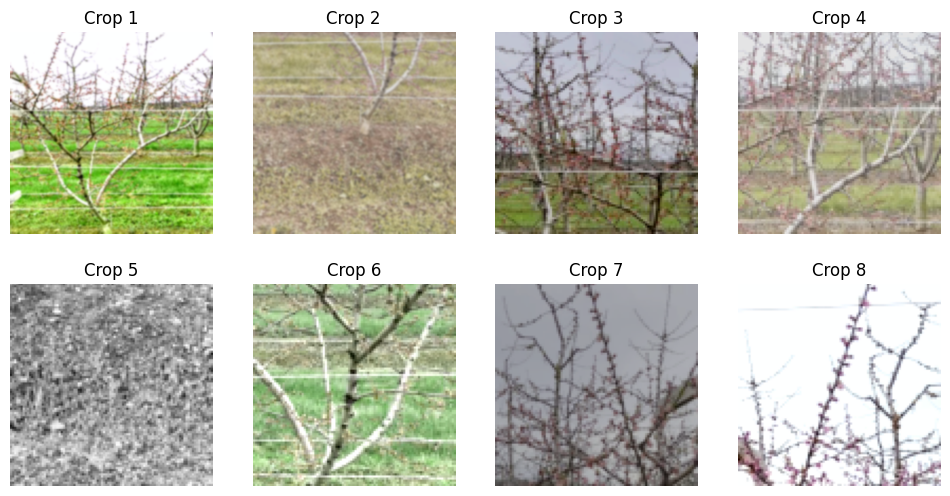

In [6]:
example_crops, example_path = dataset[0]
plt.figure(figsize=(12,6))
for i, crop in enumerate(example_crops):
    plt.subplot(2, 4, i+1)
    plt.imshow(crop.permute(1,2,0).numpy() * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
    plt.title(f'Crop {i+1}')
    plt.axis('off')

In [7]:
class DINOBackbone(nn.Module):
    def __init__(self, model_name=BACKBONE):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.projector = nn.Linear(self.model.config.hidden_size, PROJECT_DIM)

    def forward(self, x):
        features = self.model(x).last_hidden_state[:,0]
        projected = self.projector(features)
        return projected
    
class DINOHead(nn.Module):
    def __init__(self, in_dim=PROJECT_DIM, out_dim=PROJECT_DIM, hidden_dim=2048):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.mlp(x)
    
class DINO(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, x):
        features = self.backbone(x)
        output = self.head(features)
        return output

In [8]:
backbone = DINOBackbone().to(device)
head = DINOHead().to(device)
student = DINO(backbone, head).to(device)
teacher = copy.deepcopy(student).to(device)
for p in teacher.parameters():
    p.requires_grad = False

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 5380.81it/s]


In [9]:
def update_teacher(student, teacher, ema_m):
    for s_p, t_p in zip(student.parameters(), teacher.parameters()):
        t_p.data = ema_m * t_p.data + (1 - ema_m) * s_p.data
        
class Center:
    def __init__(self, dim, momentum=0.9):
        self.m = momentum
        self.center = torch.zeros(dim).to(device)

    @torch.no_grad()
    def update(self, teacher_outputs):
        batch_center = teacher_outputs.mean(dim=0)
        self.center = self.m * self.center + (1 - self.m) * batch_center
       
center = Center(PROJECT_DIM, momentum=0.9)
optimizer = torch.optim.AdamW(student.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler()

In [10]:
def dino_loss_fn(student_outputs, teacher_outputs, temp_student=STUDENT_TEMP, temp_teacher=TEACHER_TEMP):
    loss = 0.0
    n_loss_terms = 0
    t_out = [((out-center.center.unsqueeze(0))/temp_teacher).softmax(dim=-1) for out in teacher_outputs]
    s_out = [((out/temp_student)) for out in student_outputs]
    for t in t_out:
        for s in s_out:
            log_s = torch.log_softmax(s, dim=-1)
            loss_term = -(t * log_s).sum(dim=-1).mean()
            loss += loss_term
            n_loss_terms += 1
    loss = loss / n_loss_terms
    return loss

In [11]:
global_step = 0
for epoch in range(EPOCHS):
    student.train()
    epoch_loss = 0.0
    t0 = time.time()
    for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        crops_batch, paths = batch
        views = [crop.to(device, non_blocking=True) for crop in crops_batch]
        student_outputs = []
        teacher_outputs = []
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            for v in views:
                student_outputs.append(student(v))
            with torch.no_grad():
                for v in views:
                    teacher_outputs.append(teacher(v))
        loss = dino_loss_fn(student_outputs, teacher_outputs, STUDENT_TEMP, TEACHER_TEMP)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_teacher(student, teacher, EMA_M)
        with torch.no_grad():
            concat_teacher = torch.cat(teacher_outputs, dim=0)
            batch_center = concat_teacher.mean(dim=0)
            center.update(batch_center)
        epoch_loss += loss.item()
        global_step += 1
    t1 = time.time()
    print(f"Epoch {epoch+1}/{EPOCHS} loss={epoch_loss/len(loader):.4f} time={t1-t0:.1f}s")
    ckpt = {
        'student_state': student.state_dict(),
        'teacher_state': teacher.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'center': center.center.cpu().numpy()
    }
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f'dino_epoch_{epoch+1}.pth'))

Epoch 1/100:   0%|          | 0/31 [00:12<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.08 GiB is allocated by PyTorch, and 484.64 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
def load_student_from_checkpoint(path, model):
    ck = torch.load(path, map_location=device)
    model.load_state_dict(ck['student_state'], strict=False)
    model.to(device)
    model.eval()
    return model

def extract_global_features(model, image_paths, transform_single, batch_size=32):
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            imgs = []
            for p in batch_paths:
                im = Image.open(p).convert('RGB')
                x = transform_single(im).unsqueeze(0)
                imgs.append(x)
            x = torch.cat(imgs, dim=0).to(device)
            out = model(x)
            feats.append(out.cpu())
    feats = torch.cat(feats, dim=0)
    return feats

transform_single = transforms.Compose([
    transforms.Resize(int(input_size*1.14)),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])